In [26]:
import pandas as pd
import numpy as np

df1 = pd.read_csv("../data/raw/pl_25-26.csv")
df2 = pd.read_csv("../data/raw/pl_24-25.csv")
df3 = pd.read_csv("../data/raw/pl_23-24.csv")
df4 = pd.read_csv("../data/raw/pl_26-27_manual.csv")
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

df1['Season'] = '2025/26'
df2['Season'] = '2024/25'
df3['Season'] = '2023/24'
df4['Season'] = '2026/27'

df = pd.concat([df1, df2, df3, df4], ignore_index=True)

print(df.shape)
print(df.columns.tolist())

(1146, 163)
['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BFDH', 'BFDD', 'BFDA', 'BMGMH', 'BMGMD', 'BMGMA', 'BVH', 'BVD', 'BVA', 'BWH', 'BWD', 'BWA', 'CLH', 'CLD', 'CLA', 'LBH', 'LBD', 'LBA', 'PSH', 'PSD', 'PSA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'BFEH', 'BFED', 'BFEA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'BFE>2.5', 'BFE<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'BFEAHH', 'BFEAHA', 'B365CH', 'B365CD', 'B365CA', 'BFDCH', 'BFDCD', 'BFDCA', 'BMGMCH', 'BMGMCD', 'BMGMCA', 'BVCH', 'BVCD', 'BVCA', 'BWCH', 'BWCD', 'BWCA', 'CLCH', 'CLCD', 'CLCA', 'LBCH', 'LBCD', 'LBCA', 'PSCH', 'PSCD', 'PSCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'BFECH', 'BFECD', 'BFECA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2

In [27]:
city_home = df[df['HomeTeam'] == 'Man City'].copy()
city_away = df[df['AwayTeam'] == 'Man City'].copy()

print(f"City Home: {len(city_home)}")
print(f"City Away: {len(city_away)}")
print(f"Total: {len(city_home) + len(city_away)}")

City Home: 59
City Away: 58
Total: 117


In [28]:
city_home['corners'] = city_home['HC']
city_away['corners'] = city_away['AC']

city_all = pd.concat([city_home, city_away], ignore_index=True)
print(f"Average corners per match: {city_all['corners'].mean():.2f}")
print(f"Home average: {city_home['HC'].mean():.2f}")
print(f"Away average: {city_away['AC'].mean():.2f}")
print(f"Min: {city_all['corners'].min()}")
print(f"Max: {city_all['corners'].max()}")

seasonal = city_all.groupby('Season')['corners'].agg(['mean', 'std', 'min', 'max', 'count'])

print(seasonal)

Average corners per match: 6.84
Home average: 7.39
Away average: 6.28
Min: 0
Max: 18
             mean       std  min  max  count
Season                                      
2023/24  7.421053  3.873901    0   15     38
2024/25  6.657895  3.772420    1   18     38
2025/26  6.500000  3.202617    2   15     38
2026/27  6.000000  2.000000    4    8      3


In [29]:
city_home['opponent'] = city_home['AwayTeam']
city_away['opponent'] = city_away['HomeTeam']

city_all = pd.concat([city_home, city_away], ignore_index=True)

opponent_corners = (
    city_all
    .groupby(['opponent', 'Season'])['corners']
    .agg(['mean', 'count'])
    .reset_index()
    .sort_values(['opponent', 'Season'], ascending=True)
)

print(opponent_corners.to_string())

            opponent   Season  mean  count
0            Arsenal  2023/24   5.5      2
1            Arsenal  2024/25   5.0      2
2            Arsenal  2025/26   5.0      2
3        Aston Villa  2023/24   1.0      2
4        Aston Villa  2024/25   7.0      2
5        Aston Villa  2025/26   7.5      2
6        Bournemouth  2023/24  10.0      2
7        Bournemouth  2024/25   6.5      2
8        Bournemouth  2025/26   8.0      2
9        Bournemouth  2026/27   8.0      1
10         Brentford  2023/24  11.5      2
11         Brentford  2024/25   8.5      2
12         Brentford  2025/26   6.0      2
13          Brighton  2023/24   3.0      2
14          Brighton  2024/25   4.0      2
15          Brighton  2025/26   4.0      2
16           Burnley  2023/24   6.0      2
17           Burnley  2025/26  10.5      2
18           Chelsea  2023/24   7.5      2
19           Chelsea  2024/25   2.5      2
20           Chelsea  2025/26  10.0      2
21          Coventry  2026/27   4.0      1
22    Cryst

In [30]:
city_home['Date'] = pd.to_datetime(city_home['Date'], dayfirst=True)
city_away['Date'] = pd.to_datetime(city_away['Date'], dayfirst=True)

city_home = city_home.sort_values('Date').copy()
city_away = city_away.sort_values('Date').copy()

city_home['city_rolling_corners'] = (
    city_home['HC']
    .shift(1)
    .rolling(window=5, min_periods=1)
    .mean()
)

city_away['city_rolling_corners'] = (
    city_away['AC']
    .shift(1)
    .rolling(window=5, min_periods=1)
    .mean()
)

print(city_home[['Date', 'HomeTeam', 'AwayTeam', 'HC', 'city_rolling_corners']].head(10))

          Date  HomeTeam          AwayTeam  HC  city_rolling_corners
775 2023-08-19  Man City         Newcastle   3                   NaN
794 2023-09-02  Man City            Fulham   4              3.000000
811 2023-09-23  Man City     Nott'm Forest   6              3.500000
843 2023-10-21  Man City          Brighton   2              4.333333
864 2023-11-04  Man City       Bournemouth  12              3.750000
880 2023-11-25  Man City         Liverpool   9              5.400000
899 2023-12-03  Man City         Tottenham  10              6.600000
922 2023-12-16  Man City    Crystal Palace   6              7.800000
951 2023-12-30  Man City  Sheffield United  12              7.800000
973 2024-01-31  Man City           Burnley   7              9.800000


In [31]:
home_conceded = df[['Date', 'HomeTeam', 'AC']].copy()
home_conceded.columns = ['date', 'team', 'corners_conceded']

away_conceded = df[['Date', 'AwayTeam', 'HC']].copy()
away_conceded.columns = ['date', 'team', 'corners_conceded']

all_conceded = pd.concat([home_conceded, away_conceded], ignore_index=True)

all_conceded['date'] = pd.to_datetime(all_conceded['date'], dayfirst=True)
all_conceded = all_conceded.sort_values(['team', 'date']).reset_index(drop=True)

print(all_conceded.shape)
print(all_conceded.head(10))

(2292, 3)
        date     team  corners_conceded
0 2023-08-12  Arsenal                 3
1 2023-08-21  Arsenal                 1
2 2023-08-26  Arsenal                 3
3 2023-09-03  Arsenal                 3
4 2023-09-17  Arsenal                 1
5 2023-09-24  Arsenal                 4
6 2023-09-30  Arsenal                 6
7 2023-10-08  Arsenal                 4
8 2023-10-21  Arsenal                 2
9 2023-10-28  Arsenal                 1


In [32]:
all_conceded['rolling_conceded'] = (
    all_conceded
    .groupby('team')['corners_conceded']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

print(all_conceded.head(10))

        date     team  corners_conceded  rolling_conceded
0 2023-08-12  Arsenal                 3               NaN
1 2023-08-21  Arsenal                 1          3.000000
2 2023-08-26  Arsenal                 3          2.000000
3 2023-09-03  Arsenal                 3          2.333333
4 2023-09-17  Arsenal                 1          2.500000
5 2023-09-24  Arsenal                 4          2.200000
6 2023-09-30  Arsenal                 6          2.400000
7 2023-10-08  Arsenal                 4          3.400000
8 2023-10-21  Arsenal                 2          3.600000
9 2023-10-28  Arsenal                 1          3.400000


In [33]:
all_conceded = all_conceded.dropna(subset=['rolling_conceded'])

city_all = pd.concat([city_home, city_away], ignore_index=True)
city_all['opponent'] = city_all.apply(
    lambda row: row['AwayTeam'] if row['HomeTeam'] == 'Man City' else row['HomeTeam'],
    axis=1
)

city_all['Date'] = pd.to_datetime(city_all['Date'], dayfirst=True)

city_all = city_all.merge(
    all_conceded[['date', 'team', 'rolling_conceded']],
    left_on=['Date', 'opponent'],
    right_on=['date', 'team'],
    how='left'
)

print(city_all[['opponent', 'corners', 'city_rolling_corners', 'rolling_conceded']].head(10))

           opponent  corners  city_rolling_corners  rolling_conceded
0         Newcastle        3                   NaN          5.000000
1            Fulham        4              3.000000          7.666667
2     Nott'm Forest        6              3.500000          7.600000
3          Brighton        2              4.333333          3.400000
4       Bournemouth       12              3.750000          7.000000
5         Liverpool        9              5.400000          5.400000
6         Tottenham       10              6.600000          7.200000
7    Crystal Palace        6              7.800000          4.400000
8  Sheffield United       12              7.800000          7.200000
9           Burnley        7              9.800000          6.400000


In [34]:
city_all['is_home'] = (city_all['HomeTeam'] == 'Man City').astype(int)
city_all = city_all.dropna(subset=['city_rolling_corners', 'rolling_conceded'])
print(f"Matches after dropping NaN: {len(city_all)}")
print(f"\nNaN counts:\n{city_all[['city_rolling_corners', 'rolling_conceded', 'is_home']].isna().sum()}")

Matches after dropping NaN: 114

NaN counts:
city_rolling_corners    0
rolling_conceded        0
is_home                 0
dtype: int64


In [35]:
import torch
import torch.nn as nn
import torch.optim as optim

features = ['city_rolling_corners', 'rolling_conceded', 'is_home']
target = 'corners'

X = torch.tensor(city_all[features].values, dtype=torch.float32)
y = torch.tensor(city_all[target].values, dtype=torch.float32)

print(X.shape)
print(y.shape)

torch.Size([114, 3])
torch.Size([114])


In [36]:
model = nn.Sequential(
    nn.Linear(3, 1),
    nn.Softplus()
)

criterion = nn.PoissonNLLLoss(log_input=False)
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(model)

Sequential(
  (0): Linear(in_features=3, out_features=1, bias=True)
  (1): Softplus(beta=1.0, threshold=20.0)
)


In [37]:
loss_history = []

for epoch in range(1000):
    model.train()

    y_pred = model(X).squeeze()

    loss = criterion(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

Epoch 0 | Loss: -2.4018
Epoch 100 | Loss: -6.3726
Epoch 200 | Loss: -6.4225
Epoch 300 | Loss: -6.4659
Epoch 400 | Loss: -6.4975
Epoch 500 | Loss: -6.5181
Epoch 600 | Loss: -6.5304
Epoch 700 | Loss: -6.5374
Epoch 800 | Loss: -6.5412
Epoch 900 | Loss: -6.5433


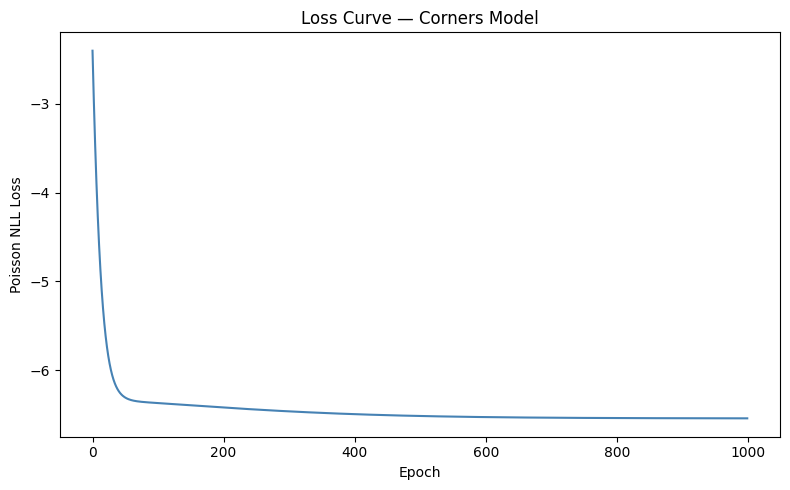

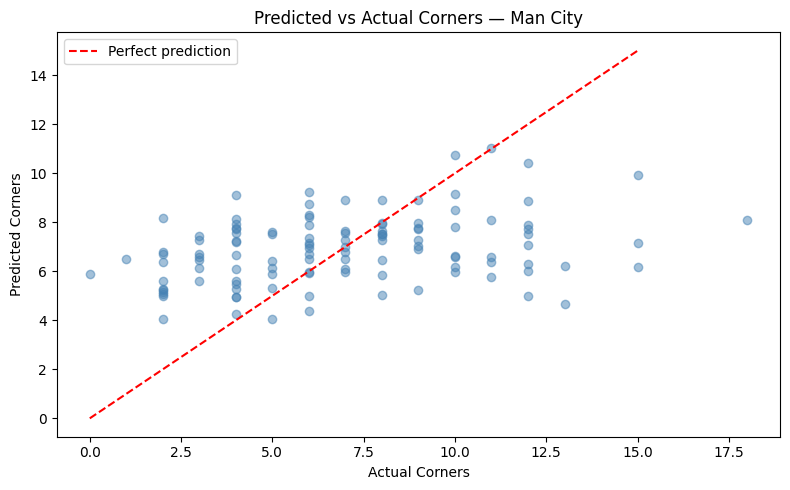

Mean predicted corners: 6.90
Mean actual corners: 6.91


In [38]:
with torch.no_grad():
    predictions = model(X).squeeze()

predictions_np = predictions.numpy()
actual_np = y.numpy()

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='steelblue')
plt.title("Loss Curve — Corners Model")
plt.xlabel("Epoch")
plt.ylabel("Poisson NLL Loss")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(actual_np, predictions_np, alpha=0.5, color='steelblue')
plt.plot([0, 15], [0, 15], color='red', linestyle='--', label='Perfect prediction')
plt.xlabel("Actual Corners")
plt.ylabel("Predicted Corners")
plt.title("Predicted vs Actual Corners — Man City")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean predicted corners: {predictions_np.mean():.2f}")
print(f"Mean actual corners: {actual_np.mean():.2f}")

In [39]:
baseline = actual_np.mean()
baseline_errors = (actual_np - baseline) ** 2
model_errors = (predictions_np - actual_np) ** 2

print(f"Baseline MSE (always predict mean): {baseline_errors.mean():.4f}")
print(f"Model MSE: {model_errors.mean():.4f}")

Baseline MSE (always predict mean): 12.8344
Model MSE: 11.4827


In [40]:
#Train/test split

train = city_all[city_all['Season'] != '2025/26']
test = city_all[city_all['Season'] == '2025/26']

#Training on data pre 25/26 season

features = ['city_rolling_corners', 'rolling_conceded', 'is_home']
target = 'corners'

X_train = torch.tensor(train[features].values, dtype=torch.float32)
y_train = torch.tensor(train[target].values, dtype=torch.float32)

X_test = torch.tensor(test[features].values, dtype=torch.float32)
y_test = torch.tensor(test[target].values, dtype=torch.float32)

print(f"X_train Shape:{X_train.shape}, X_test Shape:{X_test.shape}")
print(f"y_train Shape:{y_train.shape}, y_test Shape:{y_test.shape}")

model = nn.Sequential(
    nn.Linear(3, 1),
    nn.Softplus()
)

criterion = nn.PoissonNLLLoss(log_input=False)
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(model)

X_train Shape:torch.Size([76, 3]), X_test Shape:torch.Size([38, 3])
y_train Shape:torch.Size([76]), y_test Shape:torch.Size([38])
Sequential(
  (0): Linear(in_features=3, out_features=1, bias=True)
  (1): Softplus(beta=1.0, threshold=20.0)
)


In [41]:
loss_history = []

for epoch in range(1000):
    model.train()

    y_train_pred = model(X_train).squeeze()

    loss = criterion(y_train_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

Epoch 0 | Loss: -2.8988
Epoch 100 | Loss: -6.9606
Epoch 200 | Loss: -6.9620
Epoch 300 | Loss: -6.9633
Epoch 400 | Loss: -6.9643
Epoch 500 | Loss: -6.9651
Epoch 600 | Loss: -6.9658
Epoch 700 | Loss: -6.9663
Epoch 800 | Loss: -6.9667
Epoch 900 | Loss: -6.9671


In [42]:
with torch.no_grad():
    train_preds = model(X_train).squeeze()
    test_preds = model(X_test).squeeze()

train_mse = ((train_preds.numpy() - y_train.numpy()) ** 2).mean()
test_mse = ((test_preds.numpy() - y_test.numpy()) ** 2).mean()
baseline_mse = ((y_test.numpy() - y_train.numpy().mean()) ** 2).mean()

print(f"Train MSE: {train_mse:.4f}")
print(f"Test MSE: {test_mse:.4f}")
print(f"Baseline MSE (predict train mean): {baseline_mse:.4f}")

Train MSE: 12.4014
Test MSE: 9.8522
Baseline MSE (predict train mean): 10.3693


In [43]:
ss_res = ((y_test.numpy() - test_preds.numpy()) ** 2).sum()
ss_tot = ((y_test.numpy() - y_test.numpy().mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot

print(f"R² on test set: {r2:.4f}")

R² on test set: 0.0135


In [44]:
home_shot_conceded = df[['Date', 'HomeTeam', 'AS']].copy()
home_shot_conceded.columns = ['date', 'team', 'shots_conceded']

away_shot_conceded = df[['Date', 'AwayTeam', 'HS']].copy()
away_shot_conceded.columns = ['date', 'team', 'shots_conceded']

all_shots = pd.concat([home_shot_conceded, away_shot_conceded], ignore_index=True)

all_shots['date'] = pd.to_datetime(all_shots['date'], dayfirst=True)
all_shots = all_shots.sort_values(['team', 'date']).reset_index(drop=True)

In [45]:
all_shots['rolling_shots_conceded'] = (
    all_shots
    .groupby('team')['shots_conceded']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

print(all_shots.head(10))

        date     team  shots_conceded  rolling_shots_conceded
0 2023-08-12  Arsenal               6                     NaN
1 2023-08-21  Arsenal              14                6.000000
2 2023-08-26  Arsenal               8               10.000000
3 2023-09-03  Arsenal              10                9.333333
4 2023-09-17  Arsenal               8                9.500000
5 2023-09-24  Arsenal              13                9.200000
6 2023-09-30  Arsenal               8               10.600000
7 2023-10-08  Arsenal               4                9.400000
8 2023-10-21  Arsenal              11                8.600000
9 2023-10-28  Arsenal               2                8.800000


In [46]:
all_shots = all_shots.dropna(subset=['rolling_shots_conceded'])

city_all = pd.concat([city_home, city_away], ignore_index=True)
city_all['opponent'] = city_all.apply(
    lambda row: row['AwayTeam'] if row['HomeTeam'] == 'Man City' else row['HomeTeam'],
    axis=1
)

city_all['Date'] = pd.to_datetime(city_all['Date'], dayfirst=True)

city_all = city_all.merge(
    all_conceded[['date', 'team', 'rolling_conceded']],
    left_on=['Date', 'opponent'],
    right_on=['date', 'team'],
    how='left'
)

city_all = city_all.merge(
    all_shots[['date', 'team', 'rolling_shots_conceded']],
    left_on=['Date', 'opponent'],
    right_on=['date', 'team'],
    how='left'
)

city_all['is_home'] = (city_all['HomeTeam'] == 'Man City').astype(int)
city_all = city_all.dropna(subset=['city_rolling_corners', 'rolling_shots_conceded', 'rolling_conceded'])
print(f"Matches after dropping NaN: {len(city_all)}")
print(f"\nNaN counts:\n{city_all[['city_rolling_corners', 'rolling_conceded','rolling_shots_conceded', 'is_home']].isna().sum()}")

Matches after dropping NaN: 114

NaN counts:
city_rolling_corners      0
rolling_conceded          0
rolling_shots_conceded    0
is_home                   0
dtype: int64


In [47]:
features = ['city_rolling_corners', 'rolling_conceded', 'is_home', 'rolling_shots_conceded']
target = 'corners'

X = torch.tensor(city_all[features].values, dtype=torch.float32)
y = torch.tensor(city_all[target].values, dtype=torch.float32)

model = nn.Sequential(
    nn.Linear(4, 1),
    nn.Softplus()
)

criterion = nn.PoissonNLLLoss(log_input=False)
optimizer = optim.Adam(model.parameters(), lr=0.01)

loss_history = []

for epoch in range(1000):
    model.train()

    y_pred = model(X).squeeze()

    loss = criterion(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

Epoch 0 | Loss: 13.4373
Epoch 100 | Loss: -6.5559
Epoch 200 | Loss: -6.5619
Epoch 300 | Loss: -6.5658
Epoch 400 | Loss: -6.5696
Epoch 500 | Loss: -6.5728
Epoch 600 | Loss: -6.5755
Epoch 700 | Loss: -6.5777
Epoch 800 | Loss: -6.5792
Epoch 900 | Loss: -6.5804


In [48]:
train = city_all[city_all['Season'] != '2025/26']
test = city_all[city_all['Season'] == '2025/26']

features = ['city_rolling_corners', 'rolling_conceded', 'is_home', 'rolling_shots_conceded']
target = 'corners'

X_train = torch.tensor(train[features].values, dtype=torch.float32)
X_test = torch.tensor(test[features].values, dtype=torch.float32)

y_train = torch.tensor(train[target].values, dtype=torch.float32)
y_test = torch.tensor(test[target].values, dtype=torch.float32)

print(f"X_train Shape:{X_train.shape}, X_test Shape:{X_test.shape}")
print(f"y_train Shape:{y_train.shape}, y_test Shape:{y_test.shape}")

model = nn.Sequential(
    nn.Linear(4, 1),
    nn.Softplus()
)

criterion = nn.PoissonNLLLoss(log_input=False)
optimizer = optim.Adam(model.parameters(), lr=0.01)

loss_history = []

for epoch in range(1000):
    model.train()

    y_train_pred = model(X_train).squeeze()

    loss = criterion(y_train_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

X_train Shape:torch.Size([76, 4]), X_test Shape:torch.Size([38, 4])
y_train Shape:torch.Size([76]), y_test Shape:torch.Size([38])
Epoch 0 | Loss: -6.6809
Epoch 100 | Loss: -7.0049
Epoch 200 | Loss: -7.0109
Epoch 300 | Loss: -7.0124
Epoch 400 | Loss: -7.0132
Epoch 500 | Loss: -7.0138
Epoch 600 | Loss: -7.0144
Epoch 700 | Loss: -7.0148
Epoch 800 | Loss: -7.0151
Epoch 900 | Loss: -7.0154


In [49]:
with torch.no_grad():
    train_preds = model(X_train).squeeze()
    test_preds = model(X_test).squeeze()

train_mse = ((train_preds.numpy() - y_train.numpy()) ** 2).mean()
test_mse = ((test_preds.numpy() - y_test.numpy()) ** 2).mean()
baseline_mse = ((y_test.numpy() - y_train.numpy().mean()) ** 2).mean()

print(f"Train MSE: {train_mse:.4f}")
print(f"Test MSE: {test_mse:.4f}")
print(f"Baseline MSE (predict train mean): {baseline_mse:.4f}")

ss_res = ((y_test.numpy() - test_preds.numpy()) ** 2).sum()
ss_tot = ((y_test.numpy() - y_test.numpy().mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot

print(f"R² on test set: {r2:.4f}")

Train MSE: 11.8210
Test MSE: 9.5492
Baseline MSE (predict train mean): 10.3693
R² on test set: 0.0438


In [50]:
def train_model(seed):
    torch.manual_seed(seed)
    model = nn.Sequential(nn.Linear(4, 1), nn.Softplus())
    criterion = nn.PoissonNLLLoss(log_input=False)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    for epoch in range(1000):
        model.train()
        loss = criterion(model(X_train).squeeze(), y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return model

preds = []
for seed in range(10):
    m = train_model(seed)
    x = torch.tensor([[city_all.sort_values('Date')['corners'].tail(5).mean(),
                        all_conceded[all_conceded['team']=='Man United'].sort_values('date')['corners_conceded'].tail(5).mean(),
                        all_shots[all_shots['team']=='Man United'].sort_values('date')['shots_conceded'].tail(5).mean(),
                        0.0]], dtype=torch.float32)
    with torch.no_grad():
        preds.append(m(x).item())

preds = np.array(preds)
print(f"mean={preds.mean():.2f}  std={preds.std():.2f}  range=({preds.min():.2f}, {preds.max():.2f})")

mean=11.48  std=2.43  range=(6.85, 13.64)
